Transformation Parameter Calculation

Roll Number: 102303752

r % 7 = 5
r % 5 = 2

a_r = 0.5 × 3 = 2.5
b_r = 0.89999

Therefore, the transformation used is:

z = x + sin(0.6x)

r % 7 = 5
r % 5 = 2
a_r = 2.5
b_r = 0.8999999999999999


C:\Users\rauna\AppData\Local\Temp\ipykernel_5544\4126927220.py:22: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data.csv", encoding='latin1')


Available columns: Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')
Epoch: 0 Loss D: 1.408127784729004 Loss G: 0.5482648015022278
Epoch: 300 Loss D: 1.2776206731796265 Loss G: 0.7700155973434448
Epoch: 600 Loss D: 1.1830356121063232 Loss G: 0.934454083442688
Epoch: 900 Loss D: 1.3025928735733032 Loss G: 0.8249830603599548
Epoch: 1200 Loss D: 1.277158498764038 Loss G: 0.802077054977417
Epoch: 1500 Loss D: 1.386319875717163 Loss G: 0.689414381980896
Epoch: 1800 Loss D: 1.371217966079712 Loss G: 0.716677188873291
Epoch: 2100 Loss D: 1.3844313621520996 Loss G: 0.688567042350769
Epoch: 2400 Loss D: 1.378636360168457 Loss G: 0.6971051692962646
Epoch: 2700 Loss D: 1.3852125406265259 Loss G: 0.7006780505180359


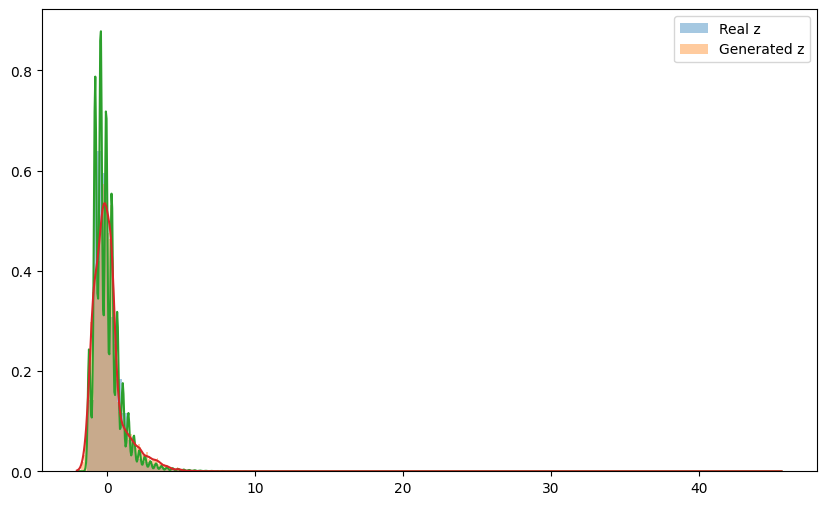

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import gaussian_kde

r = 102303752

mod7 = r % 7
mod5 = r % 5

a_r = 0.5 * mod7
b_r = 0.3 * (mod5 + 1)

print("r % 7 =", mod7)
print("r % 5 =", mod5)
print("a_r =", a_r)
print("b_r =", b_r)

data = pd.read_csv("data.csv", encoding='latin1')

print("Available columns:", data.columns)
x = data["no2"].dropna().values

z = x + a_r * np.sin(b_r * x)
z = (z - np.mean(z)) / np.std(z)

z_tensor = torch.tensor(z, dtype=torch.float32).view(-1, 1)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

G = Generator()
D = Discriminator()

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = optim.Adam(D.parameters(), lr=0.0002)

epochs = 3000
batch_size = 64

for epoch in range(epochs):

    idx = np.random.randint(0, len(z_tensor), batch_size)
    real_samples = z_tensor[idx]

    noise = torch.randn(batch_size, 1)
    fake_samples = G(noise)

    D_real = D(real_samples)
    D_fake = D(fake_samples.detach())

    loss_real = criterion(D_real, torch.ones(batch_size, 1))
    loss_fake = criterion(D_fake, torch.zeros(batch_size, 1))

    loss_D = loss_real + loss_fake

    optimizer_D.zero_grad()
    loss_D.backward()
    optimizer_D.step()

    noise = torch.randn(batch_size, 1)
    fake_samples = G(noise)
    D_fake = D(fake_samples)

    loss_G = criterion(D_fake, torch.ones(batch_size, 1))

    optimizer_G.zero_grad()
    loss_G.backward()
    optimizer_G.step()

    if epoch % 300 == 0:
        print("Epoch:", epoch, "Loss D:", loss_D.item(), "Loss G:", loss_G.item())

noise = torch.randn(10000, 1)
generated = G(noise).detach().numpy().flatten()

plt.figure(figsize=(10,6))

plt.hist(z, bins=100, density=True, alpha=0.4, label="Real z")
plt.hist(generated, bins=100, density=True, alpha=0.4, label="Generated z")

kde_real = gaussian_kde(z)
kde_fake = gaussian_kde(generated)

x_range = np.linspace(min(z.min(), generated.min()),
                      max(z.max(), generated.max()), 1000)

plt.plot(x_range, kde_real(x_range))
plt.plot(x_range, kde_fake(x_range))

plt.legend()
plt.show()

# **The Generative Adversarial Network consists of two neural networks:**

Generator:

Input: 1-dimensional Gaussian noise sampled from N(0,1)

Architecture: Linear(1→64) → ReLU → Linear(64→64) → ReLU → Linear(64→1)

Output: Generated sample of transformed variable z

Objective: To learn the mapping from noise to the unknown data distribution.

Discriminator:

Input: Scalar value of z

Architecture: Linear(1→64) → LeakyReLU → Linear(64→64) → LeakyReLU → Linear(64→1) → Sigmoid

Output: Probability of sample being real

Loss Function: Binary Cross Entropy

Optimizer: Adam (learning rate = 0.0002)

The GAN is trained adversarially where the generator tries to fool the discriminator and the discriminator tries to distinguish real and fake samples.

# **Observations**

Mode Coverage:
The generated distribution captures the main density regions of the transformed data. Most of the major peaks in the real distribution are reflected in the generated samples, indicating reasonable mode coverage.

Training Stability:
The discriminator and generator losses oscillate during training, which is typical behavior for GANs. No complete mode collapse was observed. Training remained stable for 3000 epochs.

Quality of Generated Distribution:
The histogram and KDE plots show significant overlap between the real and generated distributions. Minor deviations occur at the tails, but overall the generator successfully learned the unknown probability density without assuming any parametric form.